# Training and Testing Lasso RF with Pumping

In [20]:
#Load models 
import sys
sys.path.insert(1,'/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ')

from random_forest_sklearn import random_forest
from sklearn import linear_model

import torch
from torch.utils.data import Dataset
import xarray
from parflow.tools.io import read_pfb, write_pfb
import numpy as np
import pandas as pd

import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

from joblib import dump, load

from scipy import stats

import matplotlib.pyplot as plt

import rioxarray

In [47]:
'''
Dataloader for Climatological WTD mean difference estimation over CONUS2
'''

class WTD_Mean_Estimation_NJ_Dataset(Dataset):
    '''
    Return dataset used to contruct ML models for estimating climatological mean water table depth (WTD) difference
    over NJ.
    
    Climatological mean WTD difference = Climatological mean WTD - Long-term mean WTD

    Input data are:
                    1. climatological mean precipitation difference (cmean_P_diff);
                    2. climatological mean temperature difference (cmean_T_diff);
                    3. precipitation minus evapotranspiration (PME);
                    4. elevation (elev);
                    5. topographic slope (slope);
                    6. natural log of hydraulic conductivity (lnK);
                    7. long-term mean WTD (ldmean_WTD)
                    8. month

    Output data are: climatological mean water table depth difference (cmean_WTD_diff)

    :param in_vars:
        Input variables.
    :param out_vars:
        Output variables.
    :param grid_cell_indexes:
        Indexes of grid cells where data are obtained. Shape: [nsamples,2]
    :param month:
        month in which the data are specified
    :param base_dirs:
        Locations of data used to construct ML models. 
    '''
    def __init__(
        self,
        in_vars=None,
        out_vars=None,
        grid_cell_indexes=None,
        month=None,
        base_dirs=['/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/transit_study_data/',
                  '/home/SHARED/data/ym5379/NJ_pumping_records/']
    ):
        
        super().__init__()
        self.in_vars = in_vars
        self.out_vars = out_vars

        n_features = len(in_vars)

        x_new = np.empty([n_features,grid_cell_indexes.shape[0]],dtype=np.float32)
        y_new = np.empty([1,grid_cell_indexes.shape[0]],dtype=np.float32)

        ##Load data##    
        train_df = pd.read_csv(base_dirs[0]+'training_data_WTD_anomaly_estimation_1_3s_LP_NJ.csv')
        train_pumping = pd.read_csv(base_dirs[1]+'DGS10-3-With-HUC/HUCWithdrawal.csv')   
        train_pumping['date'] = pd.to_datetime(train_pumping.YearNumber.astype(str)+'/'+train_pumping.MonthNumber.astype(str)+'/01')
        train_df['date'] = train_df['date'].astype('datetime64[ns]')
        temp = pd.merge(train_df, train_pumping, on=['HUC14','date'])
        temp = temp.drop_duplicates(subset=['HUC14','date','wtd','P','T'])
        temp = temp.dropna()
        
        x_new[0,:] = temp['P'].to_numpy()[grid_cell_indexes]-temp['mP'].to_numpy()[grid_cell_indexes]
        x_new[1,:] = temp['T'].to_numpy()[grid_cell_indexes]-temp['mT'].to_numpy()[grid_cell_indexes]
        x_new[2,:] = temp['PME'].to_numpy()[grid_cell_indexes]
        x_new[3,:] = temp['elev'].to_numpy()[grid_cell_indexes]
        x_new[4,:] = temp['slope'].to_numpy()[grid_cell_indexes]
        x_new[5,:] = temp['lnK'].to_numpy()[grid_cell_indexes]
        x_new[6,:] = temp['mwtd'].to_numpy()[grid_cell_indexes] #long term mean WTD
        x_new[7,:] = temp['WithdrawalMG'].to_numpy()[grid_cell_indexes]
        
        y_new[0,:] = temp['wtd'].to_numpy()[grid_cell_indexes]-temp['mwtd'].to_numpy()[grid_cell_indexes]
     
        self.in_data = torch.from_numpy(np.stack(x_new)).type(torch.float32).reshape(n_features,-1)
        self.out_data = torch.from_numpy(y_new).type(torch.float32).reshape(1,-1)
        
    def __getitem__(self, idx):
        return (self.in_data[:,idx], self.out_data[:,idx])

    def __len__(self):
        return self.in_data.shape[1]

    def is_numpy(self):
        return (self.in_data.numpy(),self.out_data.numpy())


In [48]:
in_vars = ['P_mP','T_mT','PME','elev','slope','lnK','mwtd','WithdrawalMG']
out_vars = ['wtd_mwtd']

train_df = pd.read_csv('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/transit_study_data/training_data_WTD_anomaly_estimation_1_3s_LP_NJ.csv')
train_pumping = pd.read_csv('/home/SHARED/data/ym5379/NJ_pumping_records/DGS10-3-With-HUC/HUCWithdrawal.csv')   
train_pumping['date'] = pd.to_datetime(train_pumping.YearNumber.astype(str)+'/'+train_pumping.MonthNumber.astype(str)+'/01')
train_df['date'] = train_df['date'].astype('datetime64[ns]')
temp = pd.merge(train_df, train_pumping, on=['HUC14','date'])
temp = temp.drop_duplicates(subset=['HUC14','date','wtd','P','T'])
temp = temp.dropna()

obs_num = temp.shape[0]
print('Number of grid cells with observations:',obs_num)

np.random.seed(0)

dataset = WTD_Mean_Estimation_NJ_Dataset(in_vars,out_vars,
                                             grid_cell_indexes=np.arange(obs_num))

X_tensor, y_tensor = dataset[:]
X = np.swapaxes(X_tensor.numpy(),0,1) #input shape (n_samples, n_features)
y = np.swapaxes(y_tensor.numpy(),0,1)
nan_rows = np.isnan(X).any(axis=1)  # Finding rows with NaN values
X = X[~nan_rows]

#Randomly select data
train_index = np.random.choice(obs_num,int(obs_num*0.8),replace=False)

mask = np.isin(np.arange(obs_num),train_index)
test_index = np.arange(obs_num)[~mask]

#np.savetxt('train_index_3s_CONUS2.txt',train_index)
#np.savetxt('test_index_3s_CONUS2.txt',test_index)

print(train_index.shape[0])
print(test_index.shape[0])
print(np.isin(train_index,test_index).any())

np.random.shuffle(train_index) #Shuffle training data

X_train = X[train_index,:]
X_test = X[test_index,:]
y_train = y[train_index,:]
y_test = y[test_index,:]

Number of grid cells with observations: 48719
38975
9744
False


In [55]:
temp.shape

(48719, 24)

In [53]:
train_pumping.shape

(5150921, 8)

In [54]:
train_df.shape

(51461, 18)

In [49]:
#Train a lasso regression
lasso_model = linear_model.Lasso(alpha=0.0005)
lasso_model.fit(X_train,y_train)

lasso_train_results = lasso_model.predict(X_train)
lasso_test_results = lasso_model.predict(X_test)

train_r2_score = r2_score(y_train,lasso_train_results)
test_r2_score = r2_score(y_test,lasso_test_results)

train_rmse_score = mse(y_train,lasso_train_results,squared=False)
test_rmse_score = mse(y_test,lasso_test_results,squared=False)

print('Train NSE:',train_r2_score)
print('Test NSE:',test_r2_score)

print('Train RMSE:',train_rmse_score)
print('Test RMSE:',test_rmse_score)

Train NSE: 0.015737428449470348
Test NSE: 0.015273829765680924
Train RMSE: 2.2602403
Test RMSE: 2.2300012


In [50]:
#Optimal random forest hyperparameters
max_samples = 0.8
max_features = 5
n_estimators = 300
max_depth = 900
min_samples_leaf = 1

#Train RF
RF_model = random_forest(in_vars,
                          out_vars,
                          max_samples=max_samples,
                          max_features=max_features,
                          n_estimators=n_estimators,
                          max_depth=max_depth,
                          min_samples_leaf=min_samples_leaf)                      

RF_model.train((X_train,y_train - lasso_train_results.reshape(-1,1)))

dump(RF_model.rf_model,'trained_lasso_RF_for_WTD_cmean_diff_estimator_v_20230717.model')

#Calculate the median of the results of the decision trees in the random forest
estimators = RF_model.rf_model.estimators_
train_results = []
test_results = []

#Obtain results from each tree
for n in range(n_estimators):
    train_results.append(estimators[n].predict(X_train))
    test_results.append(estimators[n].predict(X_test))

/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/random_forest_sklearn.py:71: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.rf_model.fit(x,y)


train_loss 0.5728721308182446


In [51]:
train_r2_score = r2_score(y_train,np.median(np.array(train_results),axis=0)+lasso_train_results)
test_r2_score = r2_score(y_test,np.median(np.array(test_results),axis=0)+lasso_test_results)

train_rmse_score = mse(y_train,np.median(np.array(train_results),axis=0)+lasso_train_results,squared=False)
test_rmse_score = mse(y_test,np.median(np.array(test_results),axis=0)+lasso_test_results,squared=False)

train_r_score = stats.pearsonr(y_train.reshape(-1),np.mean(np.array(train_results),axis=0)+lasso_train_results)[0]
test_r_score = stats.pearsonr(y_test.reshape(-1),np.mean(np.array(test_results),axis=0)+lasso_test_results)[0]

print('Train NSE:',train_r2_score)
print('Test NSE:',test_r2_score)

print('Train RMSE:',train_rmse_score)
print('Test RMSE:',test_rmse_score)

print('Train R:',train_r_score)
print('Test R:',test_r_score)

Train NSE: 0.9993387672783762
Test NSE: 0.48840003390733044
Train RMSE: 0.0585836359952289
Test RMSE: 1.6073579667155706
Train R: 0.9574924901769591
Test R: 0.7226168383248268


[0.1894913  0.22523956 0.11280237 0.07366546 0.03470846 0.04841673
 0.1490282  0.16664791]


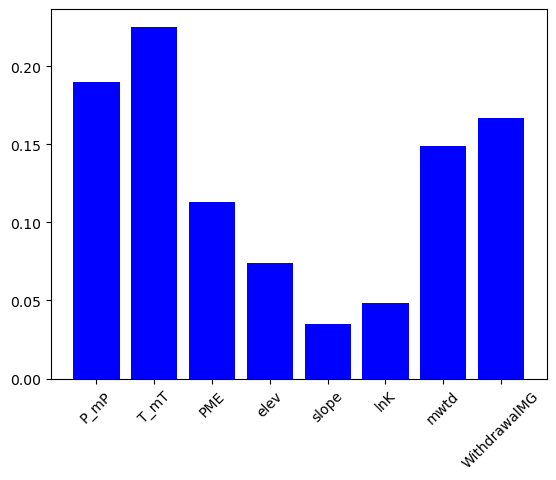

In [7]:
# feature importance
print(RF_model.rf_model.feature_importances_)
# plot
plt.bar(in_vars,RF_model.rf_model.feature_importances_,color='b')
plt.xticks(rotation=45)
plt.show()

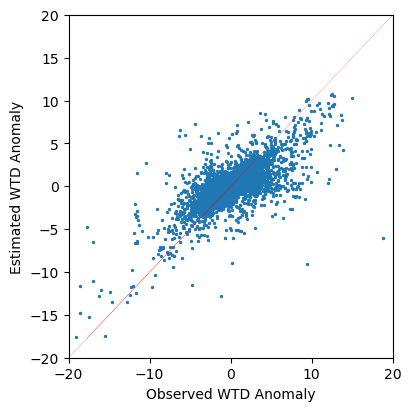

In [8]:
fig, ax1 = plt.subplots(1,1,figsize=(4,4),constrained_layout=True)
ax1.scatter(y_test,np.mean(np.array(test_results),axis=0)+lasso_test_results,s=2)
ax1.plot(y_test,y_test,'r--',lw=0.1)
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.xlabel('Observed WTD Anomaly')
plt.ylabel('Estimated WTD Anomaly')
plt.savefig('test.png',dpi=300)

In [9]:
wtd_est_obs = pd.DataFrame(np.mean(np.array(test_results),axis=0),columns = ['estimations'])
wtd_est_obs['observations'] = y_test
wtd_est_obs['differences'] = abs(wtd_est_obs.estimations - wtd_est_obs.observations)
#wtd_est_obs.to_csv('NJ_wtd_estimations_and_observations')
wtd_est_obs

,estimations,observations,differences
0,0.861885,2.801618,1.939733
1,0.034154,-0.286818,0.320972
2,0.106124,0.366182,0.260058
3,-0.033877,-0.151588,0.117711
4,0.123008,0.401421,0.278413
...,...,...,...
9739,-0.178446,-0.133937,0.044509
9740,0.219101,-0.207172,0.426273
9741,0.050046,-0.681987,0.732033
9742,-0.334540,-0.476395,0.141855


In [ ]:
result = permutation_importance(RF_model, X_test, y_test, n_repeats=30, random_state=0)
result

In [ ]:
import joblib 

# save model with joblib 
filename = 'Senior_thesis_random_forest_regression_model.sav'
joblib.dump(RF_model, filename)

# Predicting WTD in NJ Areas with Missing Data

In [31]:
'''
Dataloader for WTD anomaly estimation over NJ
'''

class WTD_Anomaly_Estimation_NJ_Dataset(Dataset):
    '''
    Return input dataset used to contruct ML models for estimating water table depth (WTD) anomaly
    over NJ for a specific date.

    Input data are:
                    1. P anomaly;
                    2. T anomaly;
                    3. precipitation minus evapotranspiration (PME);
                    4. elevation (elev);
                    5. topographic slope (slope);
                    6. natural log of hydraulic conductivity (lnK);
                    7. estimated long-term mean WTD (mwtd);
                    8. Groundwater Pumping

    Output data are: water table depth anomaly (wtd_a)

    :param in_vars:
        Input variables.
    :param out_vars:
        Output variables.
    :param date:
        Study date. Format: 'YYYY-MM-DD'.
    :param base_dirs:
        Locations of data used to construct ML models. 
    '''
    def __init__(
        self,
        in_vars=None,
        out_vars=None,
        study_date=None,
        base_dirs=['/home/SHARED/data/ym5379/WTD_RF_estimates/CONUS2_input/',
                   '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/',
                   '/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/',
                   '/hydrodata/forcing/processed_data/CONUS2/CW3E/monthly/']
    ):
        super().__init__()
        self.in_vars = in_vars
        self.out_vars = out_vars
        
        #Load location files
        x_pixel_arr_all = np.load(base_dirs[2]+'x_indexes_90m_NJ.npy')
        y_pixel_arr_all = np.load(base_dirs[2]+'y_indexes_90m_NJ.npy')
        
        x_pixel_arr_all_GW_withdrawal = np.load(base_dirs[2]+'x_indexes_90m_Withdrawals_NJ.npy')
        y_pixel_arr_all_GW_withdrawal = np.load(base_dirs[2]+'y_indexes_90m_Withdrawals_NJ.npy')
        
        mask = np.isnan(x_pixel_arr_all) + np.isnan(y_pixel_arr_all) + np.isnan(x_pixel_arr_all_GW_withdrawal) + np.isnan(y_pixel_arr_all_GW_withdrawal)

        mask[mask>0] = 1

        x_pixel_arr_all[np.isnan(x_pixel_arr_all)] = 0
        y_pixel_arr_all[np.isnan(y_pixel_arr_all)] = 0
        
        x_pixel_arr_all_GW_withdrawal[np.isnan(x_pixel_arr_all_GW_withdrawal)] = 0
        y_pixel_arr_all_GW_withdrawal[np.isnan(y_pixel_arr_all_GW_withdrawal)] = 0
        
        x_pixel_arr_all[mask] = 0
        y_pixel_arr_all[mask] = 0

        x_pixel_arr_all_GW_withdrawal[mask] = 0
        y_pixel_arr_all_GW_withdrawal[mask] = 0

        n_features = len(in_vars)
        nx = x_pixel_arr_all.shape[1]
        ny = y_pixel_arr_all.shape[0]

        x_new = np.empty([n_features,nx*ny],dtype=np.float32)
    
        ##Load input data##  
        #PME
        x_new[2,:] = read_pfb(base_dirs[0]+'1km_CONUS2_PME_fixed_GPU.pfb')[9,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                  x_pixel_arr_all.reshape(-1).astype(int)]
        #lnK
        x_new[5,:] = read_pfb(base_dirs[0]+'lnK_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                    x_pixel_arr_all.reshape(-1).astype(int)]
        
        #Elev
        elev_dataset = rioxarray.open_rasterio(base_dirs[1]+'NJ_3s_DEM.tif')
        elev_dataset = elev_dataset.astype('float32')

        elev_data = elev_dataset.data
        x_new[3,:] = elev_data[0,:,:].reshape(-1)
        
        #Slope
        slope_dataset = rioxarray.open_rasterio(base_dirs[1]+'NJ_3s_slope.tif')
        slope_data = slope_dataset.data
        #slope_data[slope_data==-9999.0] = np.nan
        slope_data[slope_data==-9999.0] = 0
        slope_data = np.tan(slope_data*np.pi/180)
        x_new[4,:] = slope_data[0,:,:].reshape(-1)
        
        #mwtd
        x_new[6,:] = rioxarray.open_rasterio(base_dirs[2]+'wtd_mean_estimate_RF_3s_CONUS_model_NJ_m_v_20230519.tif').data[0,:,:].reshape(-1)
        
        #GW pumping
        HUC14 = rioxarray.open_rasterio(base_dirs[1]+'NJ_90m_HUC14.tif').data[0,:,:][y_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int),
                                                                                                    x_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int)]
        
        #Load Pumping data
        GW_withdrawal_dataset = pd.read_csv('/home/SHARED/data/ym5379/NJ_pumping_records/DGS10-3-With-HUC/HUCWithdrawal.csv')
        GW_withdrawal_dataset['Date'] = pd.to_datetime(GW_withdrawal_dataset.YearNumber.astype(str)+'/'+GW_withdrawal_dataset.MonthNumber.astype(str)+'/01')
        GW_withdrawal_dataset = GW_withdrawal_dataset.drop(columns=['SiteName','YearNumber','MonthNumber','TransferEffectiveDate','DataSource'])

        GW_withdrawal_dataset = GW_withdrawal_dataset[GW_withdrawal_dataset['Date']==study_date]
        
        GW_withdrawal_90m_data = np.empty(ny*nx) * np.nan
        count = 0

        for HUC14_index in np.unique(HUC14[~np.isnan(HUC14)]):

            if GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)].shape[0] != 0:
                GW_withdrawal_90m_data[HUC14==HUC14_index] = GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)]['WithdrawalMG'].mean()
            else:
                count += 1
                GW_withdrawal_90m_data[HUC14==HUC14_index] = np.nan
        
        x_new[7,:] = GW_withdrawal_90m_data
        
        #P & T anomaly 
        year = pd.to_datetime(study_date).year
        month = pd.to_datetime(study_date).month

        #Water Year
        if month > 9:
            year_d = year + 1
            index = month - 10
        else:
            year_d = year 
            index = month + 12 - 10
        
        P_arr = read_pfb(base_dirs[3]+'CW3E.APCP.monthly.sum.WY'+str(year_d)+'.pfb')[index,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        T_arr = read_pfb(base_dirs[3]+'CW3E.Temp.monthly.mean.WY'+str(year_d)+'.pfb')[index,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]


        lmeanP_data = read_pfb(base_dirs[0]+'long_term_mean_monthly_precipitation_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        lmeanT_data = read_pfb(base_dirs[0]+'long_term_mean_monthly_temperature_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        
        x_new[0,:] = P_arr - lmeanP_data
        x_new[1,:] = T_arr - lmeanT_data
        
        
        #Set mask as nan
        mask = mask.reshape(-1) + np.isnan(x_new[5,:]) + np.isnan(x_new[3,:]) + np.isnan(x_new[4,:]) + np.isnan(x_new[6,:]) + np.isnan(x_new[7,:])
        mask[mask>1] = 1
        
        #x_new[:,mask] = np.nan
        x_new[:,mask] = -9999
        
       # HUC14 = GW_withdrawal_dataset['HUC14'].to_numpy().data[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                    #x_pixel_arr_all.reshape(-1).astype(int)]    
        self.in_data = torch.from_numpy(np.stack(x_new)).type(torch.float32).reshape(n_features,-1)
#         self.HUC14 = HUC14
#         self.HUC14_tensor = torch.from_numpy(HUC14).type(torch.float32)
        self.x_pixel_arr_all = torch.from_numpy(x_pixel_arr_all).type(torch.float32)
        self.mask = torch.from_numpy(mask).type(torch.float32)
        
    def __getitem__(self, idx):
        return self.in_data[:,idx], self.x_pixel_arr_all, self.mask #self.HUC14_tensor

    def __len__(self):
        return self.in_data.shape[1]

    def is_numpy(self):
        return self.in_data.numpy()

In [56]:
input_dataset = WTD_Anomaly_Estimation_NJ_Dataset(in_vars,out_vars,
                                                  study_date='2015-01-01')
    
X_tensor, X_pixel_tensor, mask_tensor = input_dataset[:]
X = np.swapaxes(X_tensor.numpy(),0,1)#input shape (n_samples, n_features)
X_pixel_array = X_pixel_tensor.numpy()
mask_real = mask_tensor.numpy()
#HUC14 = HUC14_tensor.numpy()

In [9]:
np.where(X != -9999)

(array([  82245,   82245,   82245, ..., 6028627, 6028627, 6028627]),
 array([0, 1, 2, ..., 5, 6, 7]))

In [57]:
lasso_results = lasso_model.predict(X)
results = []

#Obtain results from each tree
for n in range(n_estimators):
    results.append(estimators[n].predict(X))

In [58]:
predictions = np.mean(np.array(results),axis=0)+lasso_results
len(predictions) #6260800
predictions
# These are the predictions when I set the mask to -9999

array([7160.7805225, 7160.7805225, 7160.7805225, ..., 7160.7805225,
       7160.7805225, 7160.7805225])

In [59]:
# THIS WORKS
# Create a df to store wtd predictions
wtd_pred_df = pd.DataFrame()
wtd_pred_df['wtd_pred'] = pd.DataFrame(predictions)

# X and Y pixel/grid cells 
X_pixel_array[np.where(X_pixel_array == 0)] = np.nan
not_zero = np.where(X_pixel_array != 0)
Y_pixel = not_zero[0]
X_pixel = not_zero[1]
wtd_pred_df['Y'] = pd.DataFrame(Y_pixel, dtype="float64")
wtd_pred_df['X'] = pd.DataFrame(X_pixel, dtype="float64")

# new df with all info and drop nan grid cells
data_df = pd.DataFrame()
average_values = wtd_pred_df.groupby(['Y','X','wtd_pred']).mean()
data_df = average_values.reset_index()
data_df.columns = ['Y','X','wtd_est']
data_df.to_csv('wtd_predictions.csv')
data_df = data_df[data_df['wtd_est'] != 7160.780522503629]
data_df
# indices = np.where(mask_nan_pumping)[0]
# data_df[indices]['wtd_est'] == -9999

,Y,X,wtd_est
82245,39.0,1125.0,-1.088365
82246,39.0,1126.0,-1.147040
82247,39.0,1127.0,-1.103001
82248,39.0,1128.0,-1.144988
82249,39.0,1129.0,-1.142674
...,...,...,...
6028623,2898.0,783.0,-0.860417
6028624,2898.0,784.0,-0.807755
6028625,2898.0,785.0,-0.762991
6028626,2898.0,786.0,-0.820808


In [32]:
np.where(wtd_pred_df['wtd_pred'] != 7160.780522503629)
wtd_pred_df['wtd_pred'][82245]

-0.7137841816494862

In [34]:
data_df

,Y,X,wtd_est
82245,39.0,1125.0,-0.713784
82246,39.0,1126.0,-0.784169
82247,39.0,1127.0,-0.727384
82248,39.0,1128.0,-0.736840
82249,39.0,1129.0,-0.764723
...,...,...,...
6028623,2898.0,783.0,-0.732016
6028624,2898.0,784.0,-0.690867
6028625,2898.0,785.0,-0.780788
6028626,2898.0,786.0,-0.834881


In [14]:
# January
df = data_df[data_df['wtd_est'] != 7160.780522503629]
max_val = df['wtd_est'].max() 
min_val = df['wtd_est'].min() 
mean_val = df['wtd_est'].mean()
med_val = df['wtd_est'].median()
std_val = df['wtd_est'].std()
print("Maximum:", max_val)
print("Minimum:", min_val)
print("Mean:", mean_val)
print("Median:", med_val)
print("STD:", std_val)

Maximum: 12.216438727912804
Minimum: -8.943470953206221
Mean: -0.2108234102388289
STD: 0.6184790651041164


In [13]:
# July
df = data_df[data_df['wtd_est'] != 7160.780522503629]
max_val = df['wtd_est'].max() 
min_val = df['wtd_est'].min() 
mean_val = df['wtd_est'].mean()
med_val = df['wtd_est'].median()
std_val = df['wtd_est'].std()
print("Maximum:", max_val)
print("Minimum:", min_val)
print("Mean:", mean_val)
print("Median:", med_val)
print("STD:", std_val)

Maximum: 14.461813471888503
Minimum: -5.62296763047576
Mean: 0.5382851655102564
Median: 0.4605853283281127
STD: 0.6055619870875414


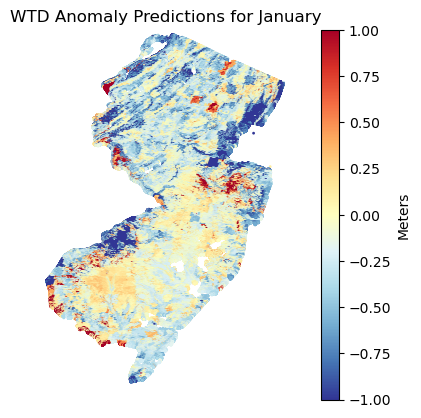

In [60]:
X_pixel_array = np.ones((1, 1))  # Replace this with your image data
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(data_df['X'], data_df['Y'], c=data_df['wtd_est'], cmap='RdYlBu_r', s=1, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar().set_label('Meters')
plt.title('WTD Anomaly Predictions for January')
plt.axis('off')
plt.savefig('wtd_pred_jan.png', dpi=300)

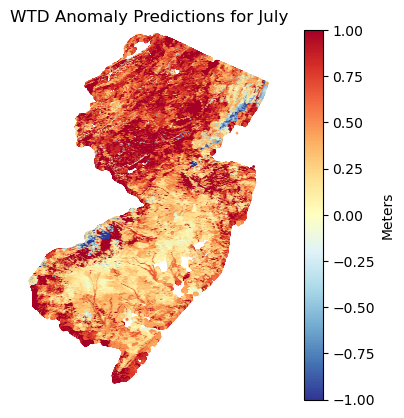

In [41]:
X_pixel_array = np.ones((1, 1))  # Replace this with your image data
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(data_df['X'], data_df['Y'], c=data_df['wtd_est'], cmap='RdYlBu_r', s=1, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar().set_label('Meters')
plt.title('WTD Anomaly Predictions for July')
plt.axis('off')
plt.savefig('wtd_pred.png', dpi=300)

In [ ]:
filtered_df = train_df[train_df['date'] == '2015-01-01']

X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(filtered_df['x'], filtered_df['y'], c=filtered_df['wtd']-filtered_df['mwtd'], cmap='RdYlBu_r', s=4, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar().set_label('m')
plt.title('WTD Anomaly Observations in January')
plt.axis('off')
plt.savefig('wtd_anomaly.png', dpi=300)

In [ ]:
filtered_df = train_df[train_df['date'] == '2015-07-01']

X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(filtered_df['x'], filtered_df['y'], c=filtered_df['wtd']-filtered_df['mwtd'], cmap='RdYlBu_r', s=4, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar().set_label('m')
plt.title('WTD Anomaly Observations in July')
plt.axis('off')
plt.savefig('wtd_anomaly.png', dpi=300)

In [ ]:
X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(train_df['x'], train_df['y'], c=train_df['wtd']-train_df['mwtd'], cmap='RdYlBu_r', s=4, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar().set_label('m')
plt.title('WTD Anomalies')
plt.axis('off')
plt.savefig('wtd_anomaly.png', dpi=300)

Text(0.5, 1.0, 'Histogram of Water Table Depth Estimates')

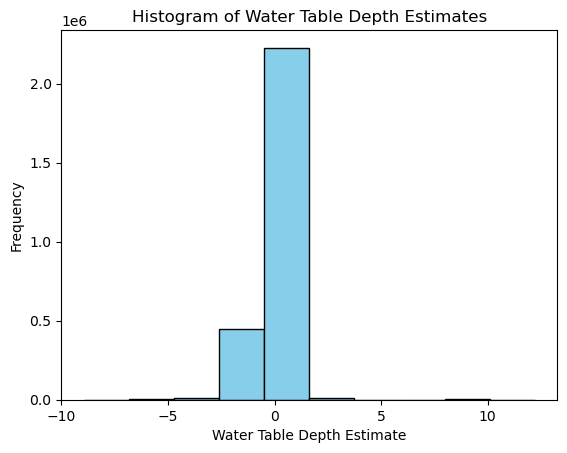

In [16]:
plt.hist(data_df['wtd_est'], bins=10, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Water Table Depth Estimate')
plt.ylabel('Frequency')
plt.title('Histogram of Water Table Depth Estimates')

In [198]:
filtered_data = data_df[(data_df['wtd_est'] < 100)]
filtered_data

,Y,X,wtd_est
82245,39.0,1125.0,-0.713784
82246,39.0,1126.0,-0.784169
82247,39.0,1127.0,-0.727384
82248,39.0,1128.0,-0.736840
82249,39.0,1129.0,-0.764723
...,...,...,...
6028623,2898.0,783.0,-0.732016
6028624,2898.0,784.0,-0.690867
6028625,2898.0,785.0,-0.780788
6028626,2898.0,786.0,-0.834881


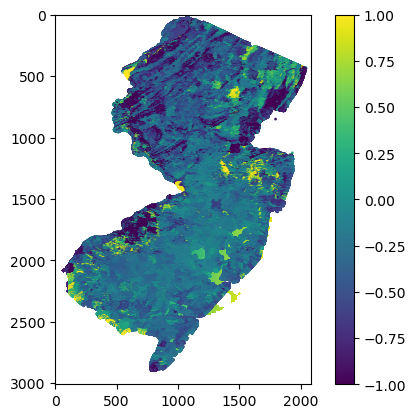

In [144]:
X_pixel_array[np.where(X_pixel_array == 0)] = np.nan
plt.imshow(X_pixel_array)
plt.scatter(data_df['X'], data_df['Y'], c=data_df['wtd_est'], cmap='viridis', s=1, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

#data_df['Y'].to_csv('wtd-mwtd_for_NJ.csv')

In [183]:
# Create a df to store wtd predictions
wtd_pred_df = pd.DataFrame()
wtd_pred_df['wtd_pred'] = pd.DataFrame(predictions)

# X and Y pixel/grid cells
not_zero = np.where(x_pixel_arr_all != 0)
Y_pixel_array = not_zero[0]
X_pixel_array = not_zero[1]
wtd_pred_df['Y'] = pd.DataFrame(Y_pixel_array, dtype="float64")
wtd_pred_df['X'] = pd.DataFrame(X_pixel_array, dtype="float64")

# new df with all info and drop nan grid cells
data_df = pd.DataFrame()
average_values = wtd_pred_df.groupby(['Y','X','wtd_pred']).mean()
data_df = average_values.reset_index()
data_df.columns = ['Y','X','wtd_est']
data_df = data_df[data_df['wtd_est'] != -0.04878455968263251]
data_df
#data_df['HUC14'] = pd.DataFrame(huc14, dtype="float64")
#data_df.to_csv('data_df.csv', index=False)

,Y,X,wtd_est
5237,2.0,1077.0,-0.223972
5238,2.0,1078.0,-0.509765
7315,3.0,1075.0,-0.174295
7316,3.0,1076.0,-0.205273
7317,3.0,1077.0,-0.249006
...,...,...,...
6028623,2898.0,783.0,-0.732016
6028624,2898.0,784.0,-0.690867
6028625,2898.0,785.0,-0.780788
6028626,2898.0,786.0,-0.834881


In [ ]:
# This map is for when we assume 0 for data that we don't have (big assumption)
plt.imshow(x_pixel_arr_all)
plt.scatter(data_df['X'], data_df['Y'], c=data_df['wtd_est'], cmap='viridis', s=1, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

In [92]:
x_pixel_arr_all = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_NJ.npy')
y_pixel_arr_all = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/y_indexes_90m_NJ.npy')
        
x_pixel_arr_all_GW_withdrawal = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_Withdrawals_NJ.npy')
y_pixel_arr_all_GW_withdrawal = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/y_indexes_90m_Withdrawals_NJ.npy')
        
mask = np.isnan(x_pixel_arr_all) + np.isnan(y_pixel_arr_all) + np.isnan(x_pixel_arr_all_GW_withdrawal) + np.isnan(y_pixel_arr_all_GW_withdrawal)

mask[mask>0] = 1

x_pixel_arr_all[np.isnan(x_pixel_arr_all)] = 0
y_pixel_arr_all[np.isnan(y_pixel_arr_all)] = 0

x_pixel_arr_all[mask] = 0
y_pixel_arr_all[mask] = 0


s = np.where(x_pixel_arr_all != 0)
len(s[0])

6260800

# Only mapping areas with groundwater pumping

In [109]:
mask = np.isnan(x_pixel_arr_all) + np.isnan(y_pixel_arr_all) + np.isnan(x_pixel_arr_all_GW_withdrawal) + np.isnan(y_pixel_arr_all_GW_withdrawal)
mask[mask>0] = 1

n_features = len(in_vars)
nx = x_pixel_arr_all_GW_withdrawal.shape[1]
ny = y_pixel_arr_all_GW_withdrawal.shape[0]

x_pixel_arr_all_GW_withdrawal[np.isnan(x_pixel_arr_all_GW_withdrawal)] = 0
y_pixel_arr_all_GW_withdrawal[np.isnan(y_pixel_arr_all_GW_withdrawal)] = 0

x_pixel_arr_all_GW_withdrawal[mask] = 0
y_pixel_arr_all_GW_withdrawal[mask] = 0

In [110]:
HUC14 = rioxarray.open_rasterio('/home/SHARED/data/ym5379/NJ_experiment/NJ_data/NJ_90m_HUC14.tif').data[0,:,:][y_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int),
                                                                                                    x_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int)]

GW_withdrawal_dataset = pd.read_csv('/home/SHARED/data/ym5379/NJ_pumping_records/DGS10-3-With-HUC/HUCWithdrawal.csv')
GW_withdrawal_dataset['Date'] = pd.to_datetime(GW_withdrawal_dataset.YearNumber.astype(str)+'/'+GW_withdrawal_dataset.MonthNumber.astype(str)+'/01')
GW_withdrawal_dataset = GW_withdrawal_dataset.drop(columns=['SiteName','YearNumber','MonthNumber','TransferEffectiveDate','DataSource'])

GW_withdrawal_dataset = GW_withdrawal_dataset[GW_withdrawal_dataset['Date']=='2010-01-01']
        
GW_withdrawal_90m_data = np.empty(ny*nx) * np.nan
count = 0

for HUC14_index in np.unique(HUC14[~np.isnan(HUC14)]):

    if GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)].shape[0] != 0:
        GW_withdrawal_90m_data[HUC14==HUC14_index] = GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)]['WithdrawalMG'].mean()
    else:
        count += 1
        GW_withdrawal_90m_data[HUC14==HUC14_index] = np.nan
        
len(GW_withdrawal_90m_data)

6260800

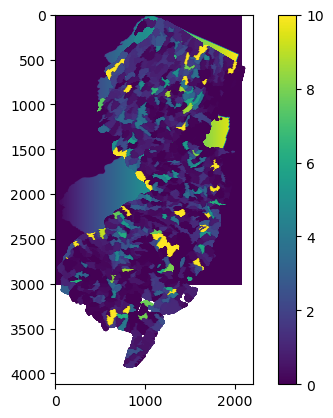

In [111]:
plt.imshow(x_pixel_arr_all_GW_withdrawal)
plt.scatter(x_pixel_arr_all_GW_withdrawal, y_pixel_arr_all_GW_withdrawal, c=GW_withdrawal_90m_data, cmap='viridis', s=1, vmin=0, vmax=10)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

In [184]:
mapping_wtd_data = np.empty(X_pixel_array.shape) * np.nan
count = 0

# Iterate over X and Y together
for X, Y in zip(np.unique(X_pixel_array[~np.isnan(X_pixel_array)]), np.unique(Y_pixel_array[~np.isnan(Y_pixel_array)])):
    # Check for existence in the DataFrame
    if len(data_df[(data_df['X'] == X) & (data_df['Y'] == Y)]) != 0:
        print(X)
        wtd_est_values = data_df.loc[(data_df['X'] == X) & (data_df['Y'] == Y), 'wtd_est'].values
        mapping_wtd_data[(X_pixel_array == X) & (Y_pixel_array == Y)] = wtd_est_values
    else:
        count += 1
        mapping_wtd_data[(X_pixel_array == X) & (Y_pixel_array == Y)] = 0
            
print(count)

611
612
613
614
615
616
617
618
619
620
621
622
623
624
625
626
627
628
629
630
631
632
633
634
635
636
637
638
639
640
641
642
643
644
645
646
647
648
649
650
651
652
653
654
655
656
657
658
659
660
661
662
663
664
665
666
667
668
669
670
671
672
673
674
675
676
677
678
679
680
681
682
683
684
685
686
687
688
689
690
691
692
693
694
695
696
697
698
699
700
701
702
703
704
705
706
707
708
709
710
711
712
713
714
715
716
717
718
719
720
721
722
723
724
725
726
727
728
729
730
731
732
733
734
735
736
737
738
739
740
741
742
743
744
745
746
747
748
749
750
751
752
753
754
755
756
757
758
759
760
761
762
763
764
765
766
767
768
769
770
771
772
773
774
775
776
777
778
779
780
781
782
783
784
785
786
787
788
789
790
791
792
793
794
795
796
797
798
799
800
801
802
803
804
805
806
807
808
809
810
811
812
813
814
815
816
817
818
819
820
821
822
823
824
825
826
827
828
829
830
831
832
833
834
835
836
837
838
839
840
841
842
843
844
845
846
847
848
849
850
851
852
853
854
855
856
857
858
859
860


In [231]:
s = np.where(GW_withdrawal_90m_data != 0)
len(s[0])

2613484

In [ ]:
#TO DO:
#make sure that the x and y pixels line up with the wtd estimation
#generate the map so that the areas with no pumping data are nan or 0

# Mapping Results on NJ

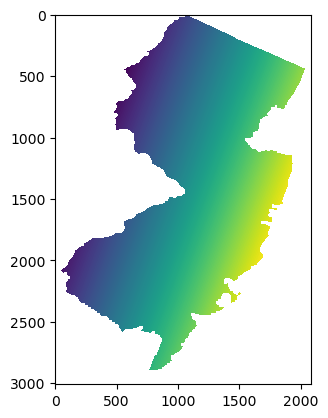

In [79]:
# set x_pixel_arr_all[mask] = np.nan and not 0
plt.imshow(x_pixel_arr_all)

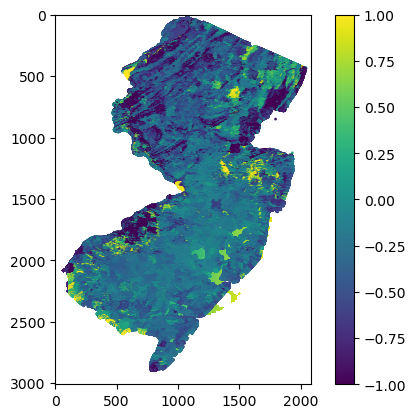

In [83]:
# This map is for when we assume 0 for data that we don't have (big assumption)
plt.imshow(x_pixel_arr_all)
plt.scatter(data_df['X'], data_df['Y'], c=data_df['wtd_est'], cmap='viridis', s=1, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

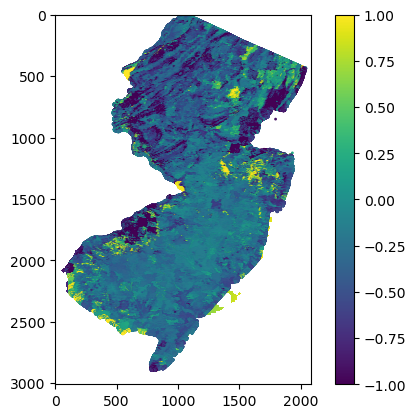

In [212]:
# This map is for when we assume 0 for data that we don't have (big assumption)
plt.imshow(x_pixel_arr_all)
plt.scatter(data_df['X'], data_df['Y'], c=data_df['wtd_est'], cmap='viridis', s=1, vmin=-1, vmax=1)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

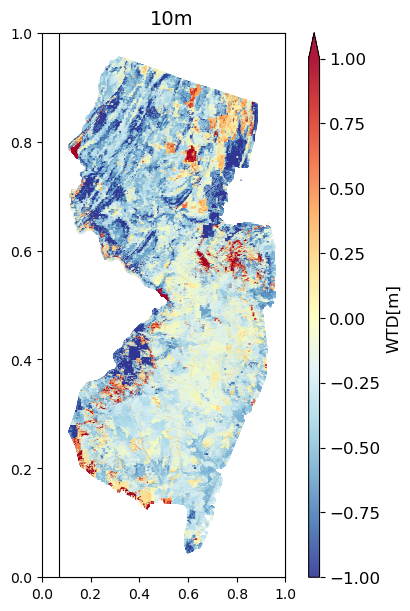

In [206]:
import matplotlib.pyplot as plt
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import rioxarray

dpath = '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/'
df = pd.read_csv('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/transit_study_data/training_data_WTD_anomaly_estimation_1_3s_LP_NJ.csv').drop(columns=['Unnamed: 0'])

elev_tif = rioxarray.open_rasterio(dpath+'NJ_10m_DEM.tif')
lons, lats = np.meshgrid(elev_tif['x'].data, elev_tif['y'].data)

# Test
fig, ax1 = plt.subplots(1, 1, figsize=(4, 6), constrained_layout=True)

# Set up the map projection with Cartopy
projection = ccrs.LambertConformal(central_longitude=-95, central_latitude=39, standard_parallels=(33, 45))
ax1 = plt.axes(projection=projection)

# Plot coastlines, countries, and states
#ax1.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
# ax1.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.8)
# ax1.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.8)

# Scatter plot with transformed coordinates
lon_indexes = data_df['X'].astype(int).values
lat_indexes = data_df['Y'].astype(int).values
lons1, lats1 = ax1.projection.transform_points(ccrs.PlateCarree(), lons[lat_indexes, lon_indexes],
                                               lats[lat_indexes, lon_indexes])[:, :2].T

# im1 = ax1.scatter(lons1, lats1, c=df['wtd']-df['mwtd'].to_numpy(), s=1, linewidths=0.1, cmap=plt.cm.RdYlBu.reversed(), alpha=0.9,
#                   norm=matplotlib.colors.LogNorm(vmin=0.5))

vmin_value = -1.0
vmax_value = 1.0
im1 = ax1.scatter(lons1, lats1, c=data_df['wtd_est'], s=1, linewidths=0.1,
                  cmap=plt.cm.RdYlBu.reversed(), alpha=0.9,
                  norm=matplotlib.colors.Normalize(vmin=vmin_value, vmax=vmax_value))

cbar1 = plt.colorbar(im1, ax=ax1, shrink=1, aspect=50, extend='max', orientation='vertical')
cbar1.set_label('WTD[m]', fontsize=12)
cbar1.ax.tick_params(labelsize=12)

ax1.set_title('10m', fontsize=14)

plt.show()

In [55]:
#Load HUC14 90m
path = '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/'
x_pixel_arr_all_GW_withdrawal = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_Withdrawals_NJ.npy')
y_pixel_arr_all_GW_withdrawal = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/y_indexes_90m_Withdrawals_NJ.npy')
x_pixel_arr_all_GW_withdrawal[np.isnan(x_pixel_arr_all_GW_withdrawal)] = 0
y_pixel_arr_all_GW_withdrawal[np.isnan(y_pixel_arr_all_GW_withdrawal)] = 0
HUC14_3s_dataset = rioxarray.open_rasterio(path+'NJ_90m_HUC14.tif').data[0,:,:][y_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int),
                                                                                                    x_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int)]
HUC14_3s_dataset

array([-9999., -9999., -9999., ..., -9999., -9999., -9999.])

In [24]:
predictions = np.mean(np.array(results),axis=0)+lasso_results
predictions
# anomalies can be negative
# These are the predictions when I set the mask to nan

array([-0.22397231, -0.50976488, -0.17429484, ..., -0.78078777,
       -0.8348811 , -0.79713857])

In [171]:
path = '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/'
HUC14_3s_dataset = rioxarray.open_rasterio(path+'NJ_90m_HUC14.tif')
HUC14_3s_dataset = HUC14_3s_dataset.data[0,:,:]
HUC14_3s_dataset[HUC14_3s_dataset==-9999] = np.nan

# nan_rows = np.isnan(HUC14_3s_dataset)
# data = HUC14_3s_dataset[~nan_rows]
# HUC14_3s_dataset

In [34]:
nan_rows = np.isnan(HUC14_3s_data)
data = HUC14_3s_data[~nan_rows]
data 

array([2.04010409e+12, 2.04010409e+12, 2.04010409e+12, ...,
       2.04030294e+12, 2.04030294e+12, 2.04030294e+12])

In [19]:
nan_rows = np.isnan(wtd_pred_df['HUC14'])
data = wtd_pred_df['HUC14'][~nan_rows]
data 

5237       2.040104e+12
5238       2.040104e+12
7315       2.040104e+12
7316       2.040104e+12
7317       2.040104e+12
               ...     
6053608    2.040302e+12
6053609    2.040302e+12
6055687    2.040302e+12
6055688    2.040302e+12
6055689    2.040302e+12
Name: HUC14, Length: 2954417, dtype: float64

In [179]:
unique_HUC14_3s_dataset = np.unique(HUC14_3s_dataset[~np.isnan(HUC14_3s_dataset)])

# Get unique values from 'HUC14' column in data_df
unique_data_df_HUC14 = data_df['HUC14'].unique()

common_values = set(unique_HUC14_3s_dataset) & set(unique_data_df_HUC14)

if common_values:
    print(f"Common values found: {common_values}")
else:
    print("No common values found.")

Common values found: {-9999.0}


In [170]:
specific_value_to_check = unique_data_df_HUC14[1]
if specific_value_to_check in unique_HUC14_3s_dataset:
    print(f"The value {specific_value_to_check} is present in unique_HUC14_3s_dataset.")
else:
    print(f"The value {specific_value_to_check} is not present in unique_HUC14_3s_dataset.")

The value 2040104091648 is not present in unique_HUC14_3s_dataset.


In [104]:
nan_rows = np.isnan(mapping_wtd_data)
wtd_data = mapping_wtd_data[~nan_rows]
nonzero_indexes = np.where(wtd_data != 0)[0]
nonzero_indexes

array([], dtype=int64)

In [ ]:
# I need to maintain the shape of huc14s but also make sure it matches with the wtd predictions
# i made the datatype the same, and i made sure that both huc14 and huc14_3s_dataset have non NaN values
# I don't understand why the values of the two variables are not matching at all
# The values in huc14 are not in the huc14_3s_dataset even though I use the same method to create them...
# none of the values for unique_data_df_HUC14 are in unique_HUC14_3s_dataset

# Mapping Grid Cells

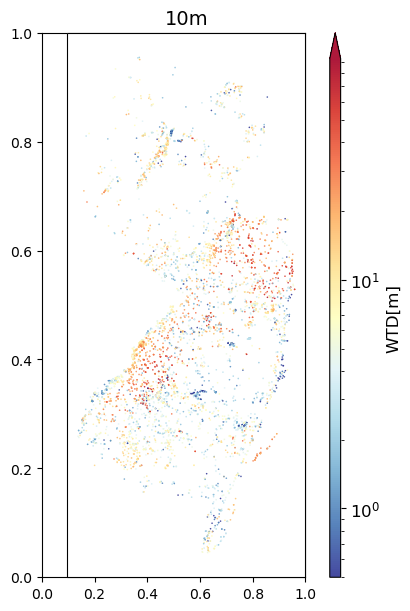

In [36]:
import matplotlib.pyplot as plt
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import rioxarray

dpath = '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/'
df = pd.read_csv('/home/jk48/training_data_WTD_mean_estimation_1_3s_LP_NJ.csv').drop(columns=['Unnamed: 0'])

elev_tif = rioxarray.open_rasterio(dpath+'NJ_10m_DEM.tif')
lons, lats = np.meshgrid(elev_tif['x'].data, elev_tif['y'].data)

# Test
fig, ax1 = plt.subplots(1, 1, figsize=(4, 6), constrained_layout=True)

# Set up the map projection with Cartopy
projection = ccrs.LambertConformal(central_longitude=-95, central_latitude=39, standard_parallels=(33, 45))
ax1 = plt.axes(projection=projection)

# Plot coastlines, countries, and states
#ax1.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
# ax1.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.8)
# ax1.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.8)

# Scatter plot with transformed coordinates
lon_indexes = df['x'].astype(int).values
lat_indexes = df['y'].astype(int).values
lons1, lats1 = ax1.projection.transform_points(ccrs.PlateCarree(), lons[lat_indexes, lon_indexes],
                                               lats[lat_indexes, lon_indexes])[:, :2].T

im1 = ax1.scatter(lons1, lats1, c=df['mwtd'].to_numpy(), s=1, linewidths=0.1, cmap=plt.cm.RdYlBu.reversed(), alpha=0.9,
                  norm=matplotlib.colors.LogNorm(vmin=0.5))

cbar1 = plt.colorbar(im1, ax=ax1, shrink=1, aspect=50, extend='max', orientation='vertical')
cbar1.set_label('WTD[m]', fontsize=12)
cbar1.ax.tick_params(labelsize=12)

ax1.set_title('10m', fontsize=14)

plt.show()

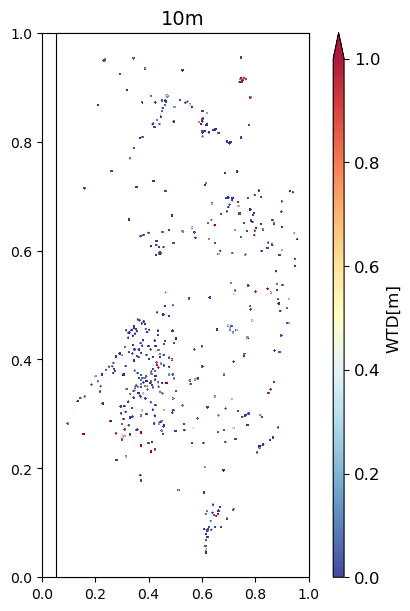

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import rioxarray

dpath = '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/'
df = pd.read_csv('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/transit_study_data/training_data_WTD_anomaly_estimation_1_3s_LP_NJ.csv').drop(columns=['Unnamed: 0'])

elev_tif = rioxarray.open_rasterio(dpath+'NJ_10m_DEM.tif')
lons, lats = np.meshgrid(elev_tif['x'].data, elev_tif['y'].data)

# Test
fig, ax1 = plt.subplots(1, 1, figsize=(4, 6), constrained_layout=True)

# Set up the map projection with Cartopy
projection = ccrs.LambertConformal(central_longitude=-95, central_latitude=39, standard_parallels=(33, 45))
ax1 = plt.axes(projection=projection)

# Plot coastlines, countries, and states
#ax1.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
# ax1.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.8)
# ax1.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.8)

# Scatter plot with transformed coordinates
lon_indexes = df['x'].astype(int).values
lat_indexes = df['y'].astype(int).values
lons1, lats1 = ax1.projection.transform_points(ccrs.PlateCarree(), lons[lat_indexes, lon_indexes],
                                               lats[lat_indexes, lon_indexes])[:, :2].T

# im1 = ax1.scatter(lons1, lats1, c=df['wtd']-df['mwtd'].to_numpy(), s=1, linewidths=0.1, cmap=plt.cm.RdYlBu.reversed(), alpha=0.9,
#                   norm=matplotlib.colors.LogNorm(vmin=0.5))

vmin_value = 0.0
vmax_value = 1.0
im1 = ax1.scatter(lons1, lats1, c=df['wtd'] - df['mwtd'].to_numpy(), s=1, linewidths=0.1,
                  cmap=plt.cm.RdYlBu.reversed(), alpha=0.9,
                  norm=matplotlib.colors.Normalize(vmin=vmin_value, vmax=vmax_value))

cbar1 = plt.colorbar(im1, ax=ax1, shrink=1, aspect=50, extend='max', orientation='vertical')
cbar1.set_label('WTD[m]', fontsize=12)
cbar1.ax.tick_params(labelsize=12)

ax1.set_title('10m', fontsize=14)

plt.show()